# Cross-Era Music Analysis Screenshot Notebook

This notebook reproduces the key analysis views used in the IEEE progress report.
Run all cells in order, then capture screenshots for the report.

1. Data quality summary table
2. Top historical genres by revival count
3. Top Spotify genre buckets by total streams
4. Cross-era comparison chart (historical revival count vs modern streams share)
5. Concentration summary table

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

quality = pd.read_csv("data/processed/spotify_data_quality_summary.csv")
spotify_genre = pd.read_csv("data/processed/spotify_genre_summary.csv")
loc_genre = pd.read_csv("data/processed/loc_genre_summary.csv")
cross = pd.read_csv("data/processed/cross_era_genre_table.csv")
concentration = pd.read_csv("data/processed/concentration_summary.csv")

print("Loaded:")
for name, df in {
    "quality": quality,
    "spotify_genre": spotify_genre,
}.items():
    print(name, df.shape)

Loaded:
quality (5, 2)
spotify_genre (9, 18)


In [4]:
# Screenshot 1: Data quality summary
quality

,metric,value
0,dataset1_rows_after_dedup,947.000000
1,dataset2_rows_after_dedup,5882.000000
2,merged_rows,947.000000
3,rows_with_genre_match,36.000000
4,genre_match_rate,0.038015


In [5]:
# Screenshot 2: Top historical genres by revival count
loc_top = loc_genre.sort_values("historical_genre_revival_count", ascending=False).head(10)
loc_top[["genre_bucket", "historical_genre_revival_count", "avg_revival_strength"]]

,genre_bucket,historical_genre_revival_count,avg_revival_strength
13,Rock,6405,12.969434
10,Popular/Pop,6022,13.958951
9,Other,5388,10.031771
8,Jazz,4872,12.660592
5,Gospel/Christian,2979,12.712281
1,Classical/Opera/Orchestral,2657,14.138313
2,Country,2280,11.438114
0,Blues,1127,9.384381
3,Electronic/Dance,1024,9.059261
14,Soundtrack/Stage/Screen,591,10.049476


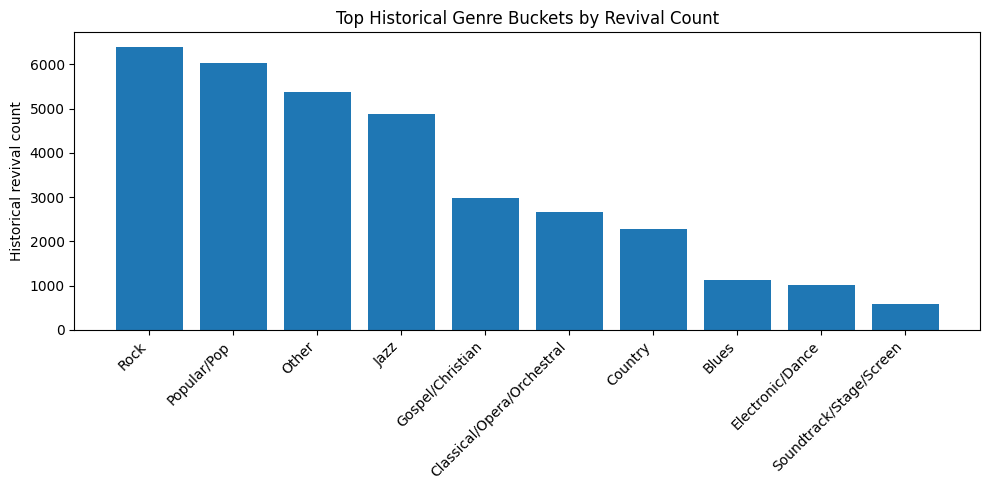

In [6]:
# Figure 1: Historical revival counts by mapped genre
loc_plot = loc_genre.sort_values("historical_genre_revival_count", ascending=False).head(10)

plt.figure()
plt.bar(loc_plot["genre_bucket"], loc_plot["historical_genre_revival_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Historical revival count")
plt.title("Top Historical Genre Buckets by Revival Count")
plt.tight_layout()
plt.show()

In [7]:
# Screenshot 3: Spotify genre summary
spotify_genre[["genre_bucket", "track_count", "matched_track_count", "total_streams", "streams_share"]]

,genre_bucket,track_count,matched_track_count,total_streams,streams_share
0,Other,920,9,4.623706e+11,0.949918
1,Electronic/Dance,12,12,1.790517e+10,0.036785
2,Rock,2,2,3.269701e+09,0.006717
3,Reggae,2,2,1.067687e+09,0.002194
4,Popular/Pop,6,6,7.871516e+08,0.001617
5,Country,2,2,5.248732e+08,0.001078
6,Folk/Bluegrass,1,1,3.996868e+08,0.000821
7,Blues,1,1,3.700686e+08,0.000760
8,Holiday/Children/Novelty,1,1,5.272300e+07,0.000108


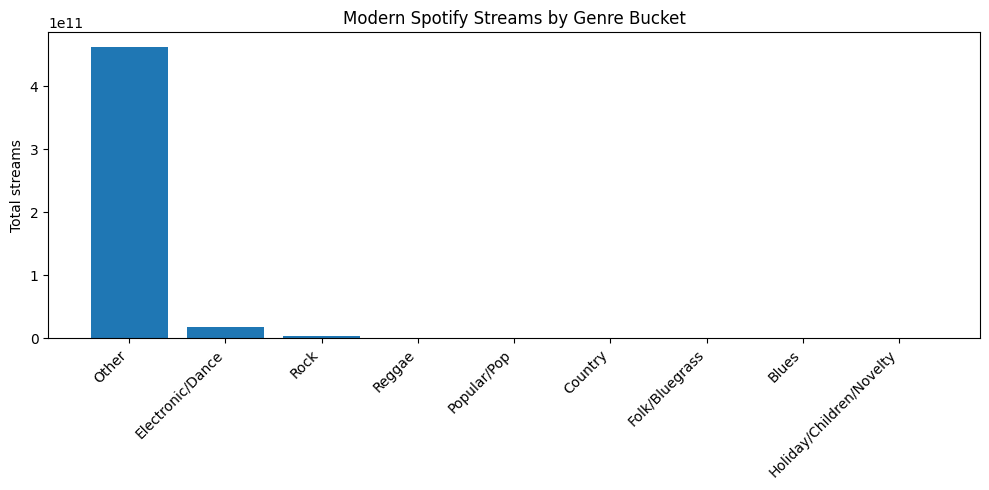

In [8]:
# Figure 2: Spotify total streams by genre bucket
spotify_plot = spotify_genre.sort_values("total_streams", ascending=False)

plt.figure()
plt.bar(spotify_plot["genre_bucket"], spotify_plot["total_streams"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total streams")
plt.title("Modern Spotify Streams by Genre Bucket")
plt.tight_layout()
plt.show()

In [9]:
# Screenshot 4: Cross-era comparison table
cross[[
    "genre_bucket",
    "historical_genre_revival_count",
    "total_streams",
    "streams_share",
    "historical_revival_rank",
    "streams_rank",
    "rank_gap_streams_vs_history"
]].sort_values("historical_genre_revival_count", ascending=False)

,genre_bucket,historical_genre_revival_count,total_streams,streams_share,historical_revival_rank,streams_rank,rank_gap_streams_vs_history
13,Rock,6405,3.269701e+09,0.006717,1.0,3.0,2.0
10,Popular/Pop,6022,7.871516e+08,0.001617,2.0,5.0,3.0
9,Other,5388,4.623706e+11,0.949918,3.0,1.0,-2.0
8,Jazz,4872,NaN,NaN,4.0,NaN,NaN
5,Gospel/Christian,2979,NaN,NaN,5.0,NaN,NaN
1,Classical/Opera/Orchestral,2657,NaN,NaN,6.0,NaN,NaN
2,Country,2280,5.248732e+08,0.001078,7.0,6.0,-1.0
0,Blues,1127,3.700686e+08,0.000760,8.0,8.0,0.0
3,Electronic/Dance,1024,1.790517e+10,0.036785,9.0,2.0,-7.0
14,Soundtrack/Stage/Screen,591,NaN,NaN,10.0,NaN,NaN


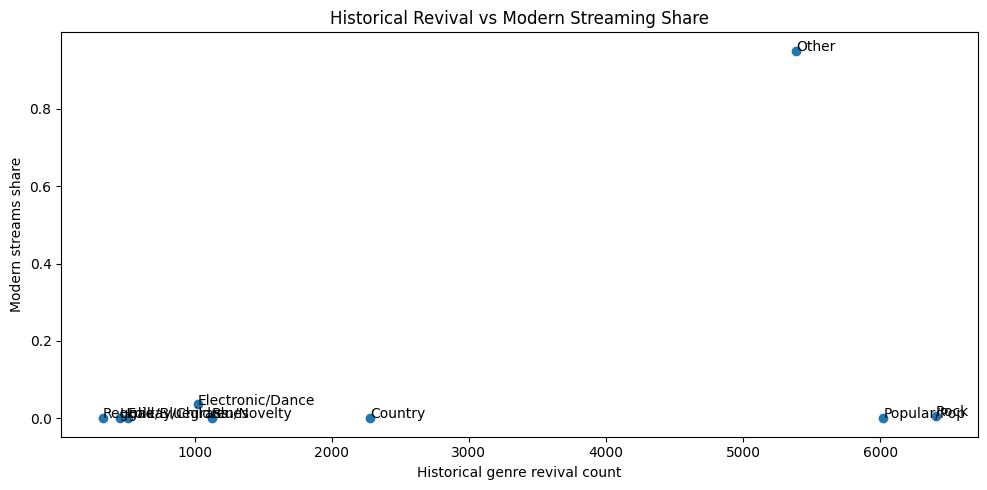

In [10]:
# Figure 3: Cross-era comparison (excluding rows with missing streams)
cross_plot = cross.dropna(subset=["total_streams"]).copy()

plt.figure()
plt.scatter(cross_plot["historical_genre_revival_count"], cross_plot["streams_share"])
for _, row in cross_plot.iterrows():
    plt.annotate(row["genre_bucket"], (row["historical_genre_revival_count"], row["streams_share"]))
plt.xlabel("Historical genre revival count")
plt.ylabel("Modern streams share")
plt.title("Historical Revival vs Modern Streaming Share")
plt.tight_layout()
plt.show()

In [11]:
# Screenshot 5: Concentration summary
concentration

,metric,value
0,spotify_track_entropy,0.254295
1,spotify_stream_entropy,0.356889
2,genre_count_in_cross_table,15.000000


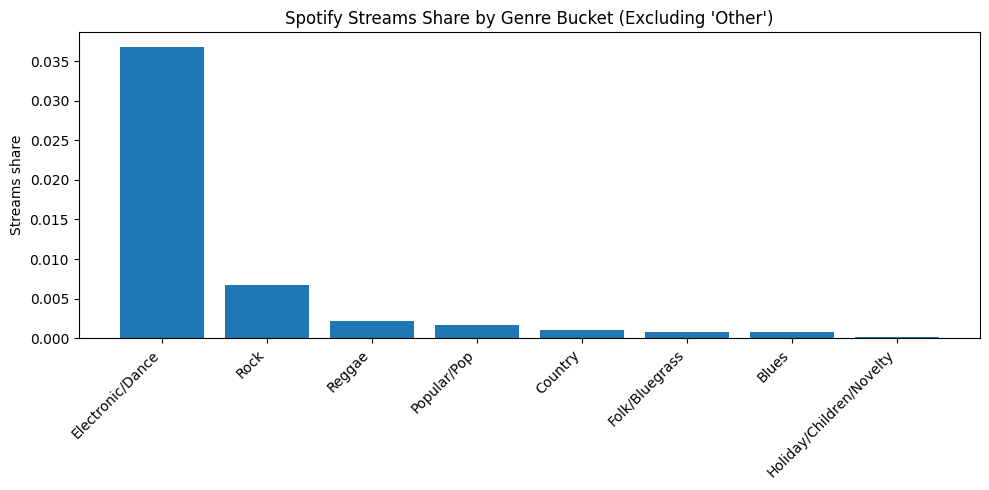

In [12]:
# Optional figure: genre share without 'Other'
spotify_no_other = spotify_genre[spotify_genre["genre_bucket"] != "Other"].copy()

plt.figure()
plt.bar(spotify_no_other["genre_bucket"], spotify_no_other["streams_share"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Streams share")
plt.title("Spotify Streams Share by Genre Bucket (Excluding 'Other')")
plt.tight_layout()
plt.show()